# 14 Binary Trading Strategy Diagnostics

## Purpose

This notebook converts model-market probability discrepancies into a simple binary trading-rule diagnostic.

The aim is not to claim a deployable trading strategy at this stage. The current dataset is still based on one Hong Kong realised event expanded across forecast timings and thresholds. Instead, the purpose is to define a clean trading framework that can later be scaled across more dates, cities and contracts.

The strategy considered here is a threshold YES-basket strategy:

- construct a model-implied probability for the threshold event;
- compare it with the market-implied threshold cost;
- buy the YES threshold basket only when the model probability exceeds the market cost by more than a specified edge buffer;
- evaluate the realised payoff using the official Hong Kong Observatory settlement outcome.

For a threshold event, the YES threshold basket can be interpreted as buying the YES outcome for all temperature bins at or above the threshold. This is a useful diagnostic because the Hong Kong Polymarket example is structured as mutually exclusive temperature-bin contracts.

## 1. Imports and paths

In [3]:
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROCESSED_DIR = Path("../data/processed/binary_trading_strategy")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 220)
pd.set_option("display.max_rows", 160)

print("Notebook run time UTC:", datetime.now(timezone.utc).isoformat())
print("Processed directory:", PROCESSED_DIR)

Notebook run time UTC: 2026-06-17T06:44:48.805405+00:00
Processed directory: ../data/processed/binary_trading_strategy


## 2. Configuration

The edge buffer controls how large the model-market probability difference must be before a trade is taken. Transaction-cost assumptions are included as sensitivity parameters.

A transaction cost of 0.01 means one percentage point per one-dollar payoff unit. This is only a simple friction proxy. It does not fully model Polymarket bid-ask spread, fees, order-book depth or market-impact costs.

In [6]:
CONFIG = {
    "edge_buffers": [0.00, 0.025, 0.05, 0.075, 0.10, 0.15, 0.20],
    "transaction_costs_per_contract": [0.00, 0.01, 0.02],
    "minimum_market_cost": 0.0,
    "maximum_market_cost": 1.25,
    "preferred_market_cost_column": "market_implied_threshold_prob_raw",
    "fallback_market_cost_column": "market_implied_threshold_prob_normalised",
}

CONFIG

{'edge_buffers': [0.0, 0.025, 0.05, 0.075, 0.1, 0.15, 0.2],
 'transaction_costs_per_contract': [0.0, 0.01, 0.02],
 'minimum_market_cost': 0.0,
 'maximum_market_cost': 1.25,
 'preferred_market_cost_column': 'market_implied_threshold_prob_raw',
 'fallback_market_cost_column': 'market_implied_threshold_prob_normalised'}

## 3. Input files

The preferred input is the Step 10 market-model discrepancy table because it contains the market probability, benchmark probabilities, realised outcome and timing variables.

In [9]:
INPUT_PATHS = {
    "step10_discrepancy": Path("../data/processed/market_model_discrepancy/hong_kong_market_model_probability_discrepancy.csv"),
    "step9_comparison": Path("../data/processed/raw_weather_benchmark/hong_kong_step7_raw_weather_benchmark_comparison.csv"),
    "step7_threshold_dataset": Path("../data/processed/threshold_dataset/hong_kong_threshold_classification_dataset.csv"),
}

for name, path in INPUT_PATHS.items():
    print(f"{name}: {path} | exists={path.exists()}")

step10_discrepancy: ../data/processed/market_model_discrepancy/hong_kong_market_model_probability_discrepancy.csv | exists=True
step9_comparison: ../data/processed/raw_weather_benchmark/hong_kong_step7_raw_weather_benchmark_comparison.csv | exists=True
step7_threshold_dataset: ../data/processed/threshold_dataset/hong_kong_threshold_classification_dataset.csv | exists=True


## 4. Helper functions

In [12]:
def read_csv_if_exists(path):
    path = Path(path)
    if path.exists():
        return pd.read_csv(path)
    return pd.DataFrame()


def clip_probability(series, eps=1e-6):
    return np.clip(pd.to_numeric(series, errors="coerce"), eps, 1 - eps)


def choose_market_cost_column(df):
    preferred = CONFIG["preferred_market_cost_column"]
    fallback = CONFIG["fallback_market_cost_column"]

    if preferred in df.columns and df[preferred].notna().any():
        return preferred, "raw_threshold_basket_cost"

    if fallback in df.columns and df[fallback].notna().any():
        return fallback, "normalised_threshold_probability_proxy"

    raise ValueError("No usable market threshold probability/cost column found.")


def identify_model_probability_sources(df):
    candidate_sources = {
        "calendar_threshold_baseline": "baseline_classifier_probability",
        "raw_weather_benchmark": "raw_forecast_threshold_probability",
    }

    sources = {
        name: col
        for name, col in candidate_sources.items()
        if col in df.columns and df[col].notna().any()
    }

    if (
        "baseline_classifier_probability" in df.columns
        and "raw_forecast_threshold_probability" in df.columns
        and df["baseline_classifier_probability"].notna().any()
        and df["raw_forecast_threshold_probability"].notna().any()
    ):
        df["average_baseline_raw_weather_probability"] = (
            df[["baseline_classifier_probability", "raw_forecast_threshold_probability"]]
            .astype(float)
            .mean(axis=1)
        )
        sources["average_baseline_raw_weather"] = "average_baseline_raw_weather_probability"

    return df, sources


def simulate_yes_basket_strategy(
    df,
    model_probability_col,
    model_source_name,
    market_cost_col,
    market_cost_type,
    edge_buffer,
    transaction_cost_per_contract,
):
    required = [
        "realised_exceeds_threshold",
        model_probability_col,
        market_cost_col,
        "threshold_c",
        "timing_label",
    ]

    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns for strategy simulation: {missing}")

    out = df.copy()

    out["model_probability"] = pd.to_numeric(out[model_probability_col], errors="coerce")
    out["market_threshold_cost"] = pd.to_numeric(out[market_cost_col], errors="coerce")
    out["realised_outcome"] = pd.to_numeric(out["realised_exceeds_threshold"], errors="coerce")

    out["model_source"] = model_source_name
    out["model_probability_column"] = model_probability_col
    out["market_cost_column"] = market_cost_col
    out["market_cost_type"] = market_cost_type
    out["edge_buffer"] = edge_buffer
    out["transaction_cost_per_contract"] = transaction_cost_per_contract

    out["expected_edge_before_cost"] = out["model_probability"] - out["market_threshold_cost"]
    out["expected_edge_after_cost"] = (
        out["expected_edge_before_cost"] - transaction_cost_per_contract
    )

    out["valid_trading_row"] = (
        out["model_probability"].between(0, 1)
        & out["market_threshold_cost"].between(
            CONFIG["minimum_market_cost"],
            CONFIG["maximum_market_cost"],
        )
        & out["realised_outcome"].isin([0, 1])
    )

    out["trade_signal"] = (
        out["valid_trading_row"]
        & (out["expected_edge_before_cost"] > edge_buffer)
    )

    out["trade_side"] = np.where(out["trade_signal"], "buy_yes_threshold_basket", "no_trade")

    # For one unit of threshold payoff:
    # buy YES basket cost = market_threshold_cost;
    # payoff = 1 if threshold event occurs, otherwise 0.
    out["gross_payoff"] = np.where(out["trade_signal"], out["realised_outcome"], 0.0)
    out["gross_cost"] = np.where(out["trade_signal"], out["market_threshold_cost"], 0.0)
    out["transaction_cost"] = np.where(out["trade_signal"], transaction_cost_per_contract, 0.0)

    out["net_profit"] = (
        out["gross_payoff"]
        - out["gross_cost"]
        - out["transaction_cost"]
    )

    out["capital_spent"] = out["gross_cost"] + out["transaction_cost"]

    out["return_on_capital"] = np.where(
        out["capital_spent"] > 0,
        out["net_profit"] / out["capital_spent"],
        np.nan,
    )

    out["winning_trade"] = np.where(
        out["trade_signal"],
        out["net_profit"] > 0,
        np.nan,
    )

    keep_cols = [
        c for c in [
            "contract_slug",
            "city",
            "target_local_date",
            "timing_label",
            "forecast_timing_category",
            "forecast_issue_time_utc",
            "market_price_time_utc",
            "threshold_c",
            "official_realised_temperature_c",
            "realised_exceeds_threshold",
            "model_source",
            "model_probability_column",
            "model_probability",
            "market_cost_column",
            "market_cost_type",
            "market_threshold_cost",
            "market_implied_threshold_prob_normalised",
            "market_implied_threshold_prob_raw",
            "expected_edge_before_cost",
            "expected_edge_after_cost",
            "edge_buffer",
            "transaction_cost_per_contract",
            "trade_signal",
            "trade_side",
            "gross_payoff",
            "gross_cost",
            "transaction_cost",
            "net_profit",
            "capital_spent",
            "return_on_capital",
            "winning_trade",
            "price_time_gap_minutes",
            "lead_time_to_valid_hours",
            "lead_time_to_day_midpoint_hours",
            "raw_forecast_daily_max_c",
            "raw_forecast_threshold_probability",
            "baseline_classifier_probability",
        ]
        if c in out.columns
    ]

    return out[keep_cols].copy()


def summarise_strategy(trades_df):
    if trades_df.empty:
        return {}

    trade_rows = trades_df[trades_df["trade_signal"]].copy()
    valid_rows = trades_df[trades_df["valid_trading_row"]] if "valid_trading_row" in trades_df.columns else trades_df

    total_profit = trade_rows["net_profit"].sum()
    total_capital = trade_rows["capital_spent"].sum()

    summary = {
        "model_source": trades_df["model_source"].iloc[0],
        "market_cost_type": trades_df["market_cost_type"].iloc[0],
        "market_cost_column": trades_df["market_cost_column"].iloc[0],
        "edge_buffer": trades_df["edge_buffer"].iloc[0],
        "transaction_cost_per_contract": trades_df["transaction_cost_per_contract"].iloc[0],
        "rows_considered": len(valid_rows),
        "number_of_trades": int(trade_rows.shape[0]),
        "trade_rate": float(trade_rows.shape[0] / len(valid_rows)) if len(valid_rows) else np.nan,
        "average_model_probability_when_trading": float(trade_rows["model_probability"].mean()) if not trade_rows.empty else np.nan,
        "average_market_cost_when_trading": float(trade_rows["market_threshold_cost"].mean()) if not trade_rows.empty else np.nan,
        "average_expected_edge_before_cost": float(trade_rows["expected_edge_before_cost"].mean()) if not trade_rows.empty else np.nan,
        "average_expected_edge_after_cost": float(trade_rows["expected_edge_after_cost"].mean()) if not trade_rows.empty else np.nan,
        "total_net_profit": float(total_profit),
        "average_net_profit_per_trade": float(trade_rows["net_profit"].mean()) if not trade_rows.empty else np.nan,
        "total_capital_spent": float(total_capital),
        "return_on_capital": float(total_profit / total_capital) if total_capital > 0 else np.nan,
        "winning_trade_rate": float(trade_rows["winning_trade"].mean()) if not trade_rows.empty else np.nan,
        "realised_event_rate_when_trading": float(trade_rows["realised_exceeds_threshold"].mean()) if not trade_rows.empty else np.nan,
    }

    return summary

## 5. Load trading input data

In [15]:
trading_df = read_csv_if_exists(INPUT_PATHS["step10_discrepancy"])
input_source = "step10_discrepancy"

if trading_df.empty:
    trading_df = read_csv_if_exists(INPUT_PATHS["step9_comparison"])
    input_source = "step9_comparison"

if trading_df.empty:
    trading_df = read_csv_if_exists(INPUT_PATHS["step7_threshold_dataset"])
    input_source = "step7_threshold_dataset"

if trading_df.empty:
    raise FileNotFoundError(
        "No suitable input dataset found. Run Notebooks 9, 11 and 12 before this notebook."
    )

print("Input source:", input_source)
print("Trading input shape:", trading_df.shape)
display(trading_df.head())

Input source: step10_discrepancy
Trading input shape: (40, 54)


,contract_slug,city,target_local_date,settlement_source,settlement_variable,official_realised_temperature_c,threshold_c,realised_exceeds_threshold,forecast_model,forecast_run_time_utc,forecast_issue_time_utc,forecast_valid_time_utc,timing_label,forecast_timing_category,lead_time_to_valid_hours,lead_time_to_day_start_hours,lead_time_to_day_midpoint_hours,lead_time_to_day_end_hours,market_implied_threshold_prob_raw,market_implied_threshold_prob_normalised,number_of_contributing_bins,average_price_time_gap_minutes,market_price_timestamp_rule,forecast_temperature_c,forecast_temperature_source,forecast_feature_status,lead_time_days_previous_run,raw_forecast_daily_max_c,raw_forecast_error_c,raw_forecast_margin_to_threshold_c,raw_forecast_threshold_probability,benchmark_type,baseline_classifier_probability,baseline_model_name,raw_forecast_brier_component,market_brier_component,baseline_brier_component,market_error,market_abs_error,market_log_score_component,baseline_classifier_error,baseline_classifier_abs_error,baseline_classifier_brier_component,baseline_classifier_log_score_component,raw_weather_error,raw_weather_abs_error,raw_weather_brier_component,raw_weather_log_score_component,baseline_minus_market_probability,abs_baseline_minus_market_probability,raw_minus_market_probability,abs_raw_minus_market_probability,raw_minus_baseline_probability,abs_raw_minus_baseline_probability
0,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,Hong Kong Observatory,Daily Maximum Temperature,32.6,24.0,1,AIFS_or_ECMWF_example,2026-05-28 12:00:00+00:00,2026-05-28 12:00:00+00:00,2026-05-30 12:00:00+00:00,two_day_valid_time_example,full_day_ex_ante,48.0,28.0,40.0,51.999722,0.9645,0.998964,10,0.1,first available Polymarket price at or after f...,NaN,not_attached_in_step_7,pending_ai_weather_feature_merge,2,30.5,-2.1,6.5,1.0,deterministic_raw_point_forecast,0.992736,logistic_regression_calendar_threshold_baseline,0.0,0.000001,0.000053,-0.001036,0.001036,0.001036,-0.007264,0.007264,0.000053,0.007291,0.0,0.0,0.0,0.000001,-0.006229,0.006229,0.001036,0.001036,0.007264,0.007264
1,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,Hong Kong Observatory,Daily Maximum Temperature,32.6,25.0,1,AIFS_or_ECMWF_example,2026-05-28 12:00:00+00:00,2026-05-28 12:00:00+00:00,2026-05-30 12:00:00+00:00,two_day_valid_time_example,full_day_ex_ante,48.0,28.0,40.0,51.999722,0.9620,0.996375,9,0.1,first available Polymarket price at or after f...,NaN,not_attached_in_step_7,pending_ai_weather_feature_merge,2,30.5,-2.1,5.5,1.0,deterministic_raw_point_forecast,0.984324,logistic_regression_calendar_threshold_baseline,0.0,0.000013,0.000246,-0.003625,0.003625,0.003632,-0.015676,0.015676,0.000246,0.015800,0.0,0.0,0.0,0.000001,-0.012050,0.012050,0.003625,0.003625,0.015676,0.015676
2,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,Hong Kong Observatory,Daily Maximum Temperature,32.6,26.0,1,AIFS_or_ECMWF_example,2026-05-28 12:00:00+00:00,2026-05-28 12:00:00+00:00,2026-05-30 12:00:00+00:00,two_day_valid_time_example,full_day_ex_ante,48.0,28.0,40.0,51.999722,0.9595,0.993786,8,0.1,first available Polymarket price at or after f...,NaN,not_attached_in_step_7,pending_ai_weather_feature_merge,2,30.5,-2.1,4.5,1.0,deterministic_raw_point_forecast,0.966503,logistic_regression_calendar_threshold_baseline,0.0,0.000039,0.001122,-0.006214,0.006214,0.006234,-0.033497,0.033497,0.001122,0.034071,0.0,0.0,0.0,0.000001,-0.027283,0.027283,0.006214,0.006214,0.033497,0.033497
3,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,Hong Kong Observatory,Daily Maximum Temperature,32.6,27.0,1,AIFS_or_ECMWF_example,2026-05-28 12:00:00+00:00,2026-05-28 12:00:00+00:00,2026-05-30 12:00:00+00:00,two_day_valid_time_example,full_day_ex_ante,48.0,28.0,40.0,51.999722,0.9540,0.988089,7,0.1,first available Polymarket price at or after f...,NaN,not_attached_in_step_7,pending_ai_weather_feature_merge,2,30.5,-2.1,3.5,1.0,deterministic_raw_point_forecast,0.

## 6. Prepare model and market probability columns

For trading diagnostics, the preferred market cost is the raw threshold-basket cost because a threshold YES trade would be implemented by buying the relevant temperature-bin YES contracts. If that column is unavailable, the notebook falls back to the normalised threshold probability as a proxy.

In [18]:
required_cols = [
    "realised_exceeds_threshold",
    "market_implied_threshold_prob_normalised",
    "threshold_c",
    "timing_label",
]

missing_required = [c for c in required_cols if c not in trading_df.columns]

if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

market_cost_col, market_cost_type = choose_market_cost_column(trading_df)
trading_df, model_sources = identify_model_probability_sources(trading_df)

print("Market cost column:", market_cost_col)
print("Market cost type:", market_cost_type)

print("Available model probability sources:")
for source, col in model_sources.items():
    print(f"- {source}: {col}")

if not model_sources:
    raise ValueError("No model probability sources found. Run Notebooks 10 and 11 before this notebook.")

display(
    trading_df[
        [
            "timing_label",
            "threshold_c",
            "realised_exceeds_threshold",
            market_cost_col,
            "market_implied_threshold_prob_normalised",
        ]
        + list(model_sources.values())
    ].head(30)
)

Market cost column: market_implied_threshold_prob_raw
Market cost type: raw_threshold_basket_cost
Available model probability sources:
- calendar_threshold_baseline: baseline_classifier_probability
- raw_weather_benchmark: raw_forecast_threshold_probability
- average_baseline_raw_weather: average_baseline_raw_weather_probability


,timing_label,threshold_c,realised_exceeds_threshold,market_implied_threshold_prob_raw,market_implied_threshold_prob_normalised,baseline_classifier_probability,raw_forecast_threshold_probability,average_baseline_raw_weather_probability
0,two_day_valid_time_example,24.0,1,0.9645,0.998964,0.992736,1.0,0.996368
1,two_day_valid_time_example,25.0,1,0.9620,0.996375,0.984324,1.0,0.992162
2,two_day_valid_time_example,26.0,1,0.9595,0.993786,0.966503,1.0,0.983251
3,two_day_valid_time_example,27.0,1,0.9540,0.988089,0.929862,1.0,0.964931
4,two_day_valid_time_example,28.0,1,0.9505,0.984464,0.858992,1.0,0.929496
5,two_day_valid_time_example,29.0,1,0.9155,0.948213,0.736781,1.0,0.868390
6,two_day_valid_time_example,30.0,1,0.8700,0.901088,0.562586,1.0,0.781293
7,two_day_valid_time_example,31.0,1,0.7050,0.730192,0.371456,0.0,0.185728
8,two_day_valid_time_example,32.0,1,0.3900,0.403936,0.213558,0.0,0.106779
9,two_day_valid_time_example,33.0,0,0.1850,0.191611,0.110933,0.0,0.055466


## 7. Run YES-basket trading-rule diagnostics

The rule is:

```text
Buy the YES threshold basket if model_probability - market_threshold_cost > edge_buffer.
```

Realised profit for one unit of payoff is:

```text
realised_outcome - market_threshold_cost - transaction_cost.
```

No position is taken when the edge condition is not satisfied.

In [21]:
all_trade_frames = []
summary_rows = []

for model_source, model_col in model_sources.items():
    for edge_buffer in CONFIG["edge_buffers"]:
        for transaction_cost in CONFIG["transaction_costs_per_contract"]:
            trades = simulate_yes_basket_strategy(
                trading_df,
                model_probability_col=model_col,
                model_source_name=model_source,
                market_cost_col=market_cost_col,
                market_cost_type=market_cost_type,
                edge_buffer=edge_buffer,
                transaction_cost_per_contract=transaction_cost,
            )

            all_trade_frames.append(trades)
            summary_rows.append(summarise_strategy(trades))

trade_diagnostics_df = pd.concat(all_trade_frames, ignore_index=True)
strategy_summary_df = pd.DataFrame(summary_rows)

strategy_summary_df = strategy_summary_df.sort_values(
    by=["total_net_profit", "return_on_capital", "number_of_trades"],
    ascending=[False, False, False],
).reset_index(drop=True)

print("Trade diagnostics shape:", trade_diagnostics_df.shape)
print("Strategy summary shape:", strategy_summary_df.shape)

display(strategy_summary_df.head(30))

Trade diagnostics shape: (2520, 35)
Strategy summary shape: (63, 18)


,model_source,market_cost_type,market_cost_column,edge_buffer,transaction_cost_per_contract,rows_considered,number_of_trades,trade_rate,average_model_probability_when_trading,average_market_cost_when_trading,average_expected_edge_before_cost,average_expected_edge_after_cost,total_net_profit,average_net_profit_per_trade,total_capital_spent,return_on_capital,winning_trade_rate,realised_event_rate_when_trading
0,raw_weather_benchmark,raw_threshold_basket_cost,market_implied_threshold_prob_raw,0.000,0.00,40,9,0.225,1.000000,0.917333,0.082667,0.082667,0.7440,0.082667,8.2560,0.090116,1.0,1.0
1,raw_weather_benchmark,raw_threshold_basket_cost,market_implied_threshold_prob_raw,0.025,0.00,40,9,0.225,1.000000,0.917333,0.082667,0.082667,0.7440,0.082667,8.2560,0.090116,1.0,1.0
2,raw_weather_benchmark,raw_threshold_basket_cost,market_implied_threshold_prob_raw,0.000,0.01,40,9,0.225,1.000000,0.917333,0.082667,0.072667,0.6540,0.072667,8.3460,0.078361,1.0,1.0
3,raw_weather_benchmark,raw_threshold_basket_cost,market_implied_threshold_prob_raw,0.025,0.01,40,9,0.225,1.000000,0.917333,0.082667,0.072667,0.6540,0.072667,8.3460,0.078361,1.0,1.0
4,raw_weather_benchmark,raw_threshold_basket_cost,market_implied_threshold_prob_raw,0.000,0.02,40,9,0.225,1.000000,0.917333,0.082667,0.062667,0.5640,0.062667,8.4360,0.066856,1.0,1.0
5,raw_weather_benchmark,raw_threshold_basket_cost,market_implied_threshold_prob_raw,0.025,0.02,40,9,0.225,1.000000,0.917333,0.082667,0.062667,0.5640,0.062667,8.4360,0.066856,1.0,1.0
6,raw_weather_benchmark,raw_threshold_basket_cost,market_implied_threshold_prob_raw,0.050,0.00,40,4,0.100,1.000000,0.866375,0.133625,0.133625,0.5345,0.133625,3.4655,0.154235,1.0,1.0
7,raw_weather_benchmark,raw_threshold_basket_cost,market_implied_threshold_prob_raw,0.050,0.01,40,4,0.100,1.000000,0.866375,0.133625,0.123625,0.4945,0.123625,3.5055,0.141064,1.0,1.0
8,raw_weather_benchmark,raw_threshold_basket_cost,market_implied_threshold_prob_raw,0.075,0.00,40,3,0.075,1.000000,0.838500,0.161500,0.161500,0.4845,0.161500,2.5155,0.192606,1.0,1.0
9,raw_weather_benchmark,raw_threshold_basket_cost,market_implied_threshold_prob_raw,0.050,0.02,40,4,0.100,1.000000,0.866375,0.133625,0.113625,0.4545,0.113625,3.5455,0.128191,1.0,1.0


## 8. Inspect trades from the best diagnostic rule

The best rule here is selected by realised net profit. This is only for inspection. It should not be treated as an optimised trading strategy because the current sample is too small.

In [24]:
if not strategy_summary_df.empty:
    best_rule = strategy_summary_df.iloc[0].to_dict()

    print("Best diagnostic rule:")
    for key in [
        "model_source",
        "edge_buffer",
        "transaction_cost_per_contract",
        "number_of_trades",
        "total_net_profit",
        "return_on_capital",
    ]:
        print(f"{key}: {best_rule.get(key)}")

    best_trades_df = trade_diagnostics_df[
        (trade_diagnostics_df["model_source"] == best_rule["model_source"])
        & (trade_diagnostics_df["edge_buffer"] == best_rule["edge_buffer"])
        & (
            trade_diagnostics_df["transaction_cost_per_contract"]
            == best_rule["transaction_cost_per_contract"]
        )
    ].copy()

    executed_best_trades_df = best_trades_df[best_trades_df["trade_signal"]].copy()

    display(executed_best_trades_df.head(50))
else:
    best_trades_df = pd.DataFrame()
    executed_best_trades_df = pd.DataFrame()

Best diagnostic rule:
model_source: raw_weather_benchmark
edge_buffer: 0.0
transaction_cost_per_contract: 0.0
number_of_trades: 9
total_net_profit: 0.7440000000000002
return_on_capital: 0.09011627906976746


,contract_slug,city,target_local_date,timing_label,forecast_timing_category,forecast_issue_time_utc,threshold_c,official_realised_temperature_c,realised_exceeds_threshold,model_source,model_probability_column,model_probability,market_cost_column,market_cost_type,market_threshold_cost,market_implied_threshold_prob_normalised,market_implied_threshold_prob_raw,expected_edge_before_cost,expected_edge_after_cost,edge_buffer,transaction_cost_per_contract,trade_signal,trade_side,gross_payoff,gross_cost,transaction_cost,net_profit,capital_spent,return_on_capital,winning_trade,lead_time_to_valid_hours,lead_time_to_day_midpoint_hours,raw_forecast_daily_max_c,raw_forecast_threshold_probability,baseline_classifier_probability
840,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,two_day_valid_time_example,full_day_ex_ante,2026-05-28 12:00:00+00:00,24.0,32.6,1,raw_weather_benchmark,raw_forecast_threshold_probability,1.0,market_implied_threshold_prob_raw,raw_threshold_basket_cost,0.9645,0.998964,0.9645,0.0355,0.0355,0.0,0.0,True,buy_yes_threshold_basket,1.0,0.9645,0.0,0.0355,0.9645,0.036807,1.0,48.0,40.0,30.5,1.0,0.992736
841,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,two_day_valid_time_example,full_day_ex_ante,2026-05-28 12:00:00+00:00,25.0,32.6,1,raw_weather_benchmark,raw_forecast_threshold_probability,1.0,market_implied_threshold_prob_raw,raw_threshold_basket_cost,0.9620,0.996375,0.9620,0.0380,0.0380,0.0,0.0,True,buy_yes_threshold_basket,1.0,0.9620,0.0,0.0380,0.9620,0.039501,1.0,48.0,40.0,30.5,1.0,0.984324
842,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,two_day_valid_time_example,full_day_ex_ante,2026-05-28 12:00:00+00:00,26.0,32.6,1,raw_weather_benchmark,raw_forecast_threshold_probability,1.0,market_implied_threshold_prob_raw,raw_threshold_basket_cost,0.9595,0.993786,0.9595,0.0405,0.0405,0.0,0.0,True,buy_yes_threshold_basket,1.0,0.9595,0.0,0.0405,0.9595,0.042209,1.0,48.0,40.0,30.5,1.0,0.966503
843,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,two_day_valid_time_example,full_day_ex_ante,2026-05-28 12:00:00+00:00,27.0,32.6,1,raw_weather_benchmark,raw_forecast_threshold_probability,1.0,market_implied_threshold_prob_raw,raw_threshold_basket_cost,0.9540,0.988089,0.9540,0.0460,0.0460,0.0,0.0,True,buy_yes_threshold_basket,1.0,0.9540,0.0,0.0460,0.9540,0.048218,1.0,48.0,40.0,30.5,1.0,0.929862
844,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,two_day_valid_time_example,full_day_ex_ante,2026-05-28 12:00:00+00:00,28.0,32.6,1,raw_weather_benchmark,raw_forecast_threshold_probability,1.0,market_implied_threshold_prob_raw,raw_threshold_basket_cost,0.9505,0.984464,0.9505,0.0495,0.0495,0.0,0.0,True,buy_yes_threshold_basket,1.0,0.9505,0.0,0.0495,0.9505,0.052078,1.0,48.0,40.0,30.5,1.0,0.858992
845,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,two_day_valid_time_example,full_day_ex_ante,2026-05-28 12:00:00+00:00,29.0,32.6,1,raw_weather_benchmark,raw_forecast_threshold_probability,1.0,market_implied_threshold_prob_raw,raw_threshold_basket_cost,0.9155,0.948213,0.9155,0.0845,0.0845,0.0,0.0,True,buy_yes_threshold_basket,1.0,0.9155,0.0,0.0845,0.9155,0.092299,1.0,48.0,40.0,30.5,1.0,0.736781
846,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,two_day_valid_time_example,full_day_ex_ante,2026-05-28 12:00:00+00:00,30.0,32.6,1,raw_weather_benchmark,raw_forecast_threshold_probability,1.0,market_implied_threshold_prob_raw,raw_threshold_basket_cost,0.8700,0.901088,0.8700,0.1300,0.1300,0.0,0.0,True,buy_yes_threshold_basket,1.0,0.8700,0.0,0.1300,0.8700,0.149425,1.0,48.0,40.0,30.5,1.0,0.562586
876,highest-temperature-in-hong-kong-on-may-30-2026,Hong Kong,2026-05-30,same_day_valid_time_example,within_day_update,2026-05-30 00:00:00+00:00,30.0,32.6,1,raw_weather_benchmark,raw_forecast_threshold_probability,1.0,market_implied_threshold_prob_raw,raw_threshold_basket_cost,0.9500,0.912584,0.9500,0.0500,0.0500,0.0,0.0,True,b

## 9. Summary by model source and edge buffer

This view fixes transaction cost at zero to show the effect of the edge buffer more clearly.

,model_source,edge_buffer,number_of_trades,trade_rate,average_expected_edge_before_cost,total_net_profit,total_capital_spent,return_on_capital,winning_trade_rate
21,average_baseline_raw_weather,0.000,4,0.100,0.024178,0.1600,3.8400,0.041667,1.0
24,average_baseline_raw_weather,0.025,2,0.050,0.031015,0.0735,1.9265,0.038152,1.0
42,average_baseline_raw_weather,0.050,0,0.000,NaN,0.0000,0.0000,NaN,NaN
45,average_baseline_raw_weather,0.075,0,0.000,NaN,0.0000,0.0000,NaN,NaN
48,average_baseline_raw_weather,0.100,0,0.000,NaN,0.0000,0.0000,NaN,NaN
51,average_baseline_raw_weather,0.150,0,0.000,NaN,0.0000,0.0000,NaN,NaN
54,average_baseline_raw_weather,0.200,0,0.000,NaN,0.0000,0.0000,NaN,NaN
58,calendar_threshold_baseline,0.000,5,0.125,0.019886,-0.0660,3.0660,-0.021526,0.6
57,calendar_threshold_baseline,0.025,2,0.050,0.027084,-0.0495,1.0495,-0.047165,0.5
27,calendar_threshold_baseline,0.050,0,0.000,NaN,0.0000,0.0000,NaN,NaN


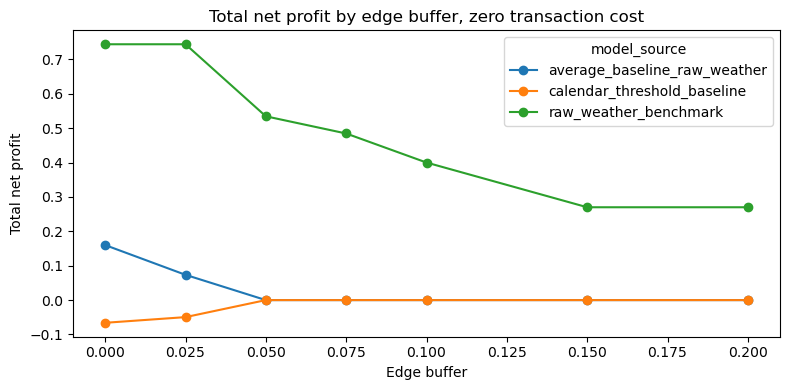

In [27]:
zero_cost_summary_df = strategy_summary_df[
    strategy_summary_df["transaction_cost_per_contract"] == 0.0
].copy()

display(
    zero_cost_summary_df.sort_values(
        ["model_source", "edge_buffer"]
    )[
        [
            "model_source",
            "edge_buffer",
            "number_of_trades",
            "trade_rate",
            "average_expected_edge_before_cost",
            "total_net_profit",
            "total_capital_spent",
            "return_on_capital",
            "winning_trade_rate",
        ]
    ]
)

if not zero_cost_summary_df.empty:
    ax = zero_cost_summary_df.pivot(
        index="edge_buffer",
        columns="model_source",
        values="total_net_profit",
    ).plot(
        marker="o",
        figsize=(8, 4),
        title="Total net profit by edge buffer, zero transaction cost",
    )
    ax.set_xlabel("Edge buffer")
    ax.set_ylabel("Total net profit")
    plt.tight_layout()
    plt.show()

## 10. Transaction-cost sensitivity

This view checks whether the diagnostic profit is robust to simple transaction-cost assumptions.

In [30]:
cost_sensitivity_df = (
    strategy_summary_df
    .groupby(["model_source", "transaction_cost_per_contract"], dropna=False)
    .agg(
        best_total_net_profit=("total_net_profit", "max"),
        best_return_on_capital=("return_on_capital", "max"),
        max_number_of_trades=("number_of_trades", "max"),
    )
    .reset_index()
)

cost_sensitivity_df

,model_source,transaction_cost_per_contract,best_total_net_profit,best_return_on_capital,max_number_of_trades
0,average_baseline_raw_weather,0.00,0.160,0.041667,4
1,average_baseline_raw_weather,0.01,0.120,0.030928,4
2,average_baseline_raw_weather,0.02,0.080,0.020408,4
3,calendar_threshold_baseline,0.00,0.000,-0.021526,5
4,calendar_threshold_baseline,0.01,0.000,-0.037227,5
5,calendar_threshold_baseline,0.02,0.000,-0.052432,5
6,raw_weather_benchmark,0.00,0.744,0.369863,9
7,raw_weather_benchmark,0.01,0.654,0.351351,9
8,raw_weather_benchmark,0.02,0.564,0.333333,9


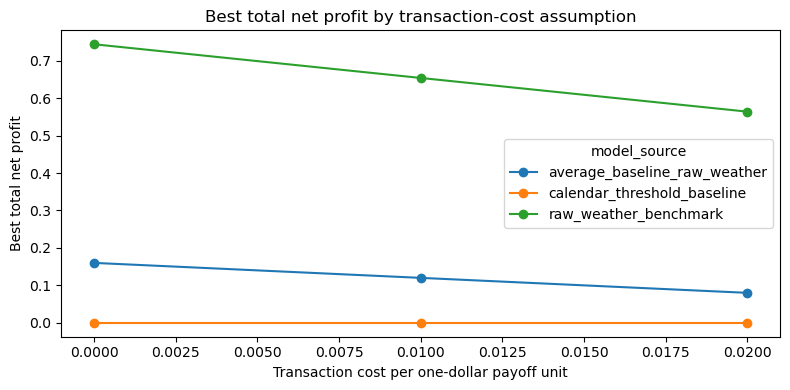

In [32]:
if not cost_sensitivity_df.empty:
    ax = cost_sensitivity_df.pivot(
        index="transaction_cost_per_contract",
        columns="model_source",
        values="best_total_net_profit",
    ).plot(
        marker="o",
        figsize=(8, 4),
        title="Best total net profit by transaction-cost assumption",
    )
    ax.set_xlabel("Transaction cost per one-dollar payoff unit")
    ax.set_ylabel("Best total net profit")
    plt.tight_layout()
    plt.show()

## 11. Trading diagnostics by threshold and timing

These tables show where trades are generated and whether profits are concentrated around particular thresholds or forecast timings.

In [35]:
if not executed_best_trades_df.empty:
    threshold_trade_summary_df = (
        executed_best_trades_df
        .groupby("threshold_c", dropna=False)
        .agg(
            number_of_trades=("trade_signal", "size"),
            realised_event_rate=("realised_exceeds_threshold", "mean"),
            average_model_probability=("model_probability", "mean"),
            average_market_cost=("market_threshold_cost", "mean"),
            average_expected_edge=("expected_edge_before_cost", "mean"),
            total_net_profit=("net_profit", "sum"),
            average_return_on_capital=("return_on_capital", "mean"),
        )
        .reset_index()
        .sort_values("threshold_c")
    )
else:
    threshold_trade_summary_df = pd.DataFrame()

threshold_trade_summary_df

,threshold_c,number_of_trades,realised_event_rate,average_model_probability,average_market_cost,average_expected_edge,total_net_profit,average_return_on_capital
0,24.0,1,1.0,1.0,0.9645,0.0355,0.0355,0.036807
1,25.0,1,1.0,1.0,0.9620,0.0380,0.0380,0.039501
2,26.0,1,1.0,1.0,0.9595,0.0405,0.0405,0.042209
3,27.0,1,1.0,1.0,0.9540,0.0460,0.0460,0.048218
4,28.0,1,1.0,1.0,0.9505,0.0495,0.0495,0.052078
5,29.0,1,1.0,1.0,0.9155,0.0845,0.0845,0.092299
6,30.0,2,1.0,1.0,0.9100,0.0900,0.1800,0.101028
7,31.0,1,1.0,1.0,0.7300,0.2700,0.2700,0.369863


In [37]:
timing_cols = [c for c in ["timing_label", "forecast_timing_category"] if c in executed_best_trades_df.columns]

if not executed_best_trades_df.empty and timing_cols:
    timing_trade_summary_df = (
        executed_best_trades_df
        .groupby(timing_cols, dropna=False)
        .agg(
            number_of_trades=("trade_signal", "size"),
            realised_event_rate=("realised_exceeds_threshold", "mean"),
            average_model_probability=("model_probability", "mean"),
            average_market_cost=("market_threshold_cost", "mean"),
            average_expected_edge=("expected_edge_before_cost", "mean"),
            total_net_profit=("net_profit", "sum"),
            average_return_on_capital=("return_on_capital", "mean"),
        )
        .reset_index()
    )
else:
    timing_trade_summary_df = pd.DataFrame()

timing_trade_summary_df

,timing_label,forecast_timing_category,number_of_trades,realised_event_rate,average_model_probability,average_market_cost,average_expected_edge,total_net_profit,average_return_on_capital
0,same_day_valid_time_example,within_day_update,2,1.0,1.0,0.840000,0.160000,0.320,0.211247
1,two_day_valid_time_example,full_day_ex_ante,7,1.0,1.0,0.939429,0.060571,0.424,0.065791


## 12. Trading-rule caveats

This diagnostic intentionally uses a simplified setup.

Important caveats:

1. The current sample contains one realised Hong Kong event, so strategy results are not statistically meaningful yet.
2. The threshold YES trade is represented as a basket of temperature-bin YES contracts. This assumes the bins are mutually exclusive and that the relevant contracts can be traded at the sampled prices.
3. The notebook does not model bid-ask spreads, order-book depth, slippage, fees, partial fills or market impact.
4. The strategy is evaluated after the realised temperature is known, but the trade signal only uses model and market probabilities available at the forecast issue time.
5. A robust dissertation result will require the same framework across more dates, thresholds, cities and market conditions.

## 13. Save outputs

In [41]:
trade_diagnostics_output_path = PROCESSED_DIR / "hong_kong_binary_trade_diagnostics.csv"
strategy_summary_output_path = PROCESSED_DIR / "hong_kong_binary_strategy_summary.csv"
zero_cost_summary_output_path = PROCESSED_DIR / "hong_kong_binary_strategy_zero_cost_summary.csv"
cost_sensitivity_output_path = PROCESSED_DIR / "hong_kong_binary_strategy_cost_sensitivity.csv"
threshold_trade_summary_output_path = PROCESSED_DIR / "hong_kong_binary_strategy_by_threshold.csv"
timing_trade_summary_output_path = PROCESSED_DIR / "hong_kong_binary_strategy_by_timing.csv"

trade_diagnostics_df.to_csv(trade_diagnostics_output_path, index=False)
strategy_summary_df.to_csv(strategy_summary_output_path, index=False)
zero_cost_summary_df.to_csv(zero_cost_summary_output_path, index=False)
cost_sensitivity_df.to_csv(cost_sensitivity_output_path, index=False)

if not threshold_trade_summary_df.empty:
    threshold_trade_summary_df.to_csv(threshold_trade_summary_output_path, index=False)

if not timing_trade_summary_df.empty:
    timing_trade_summary_df.to_csv(timing_trade_summary_output_path, index=False)

print("Saved trade diagnostics:", trade_diagnostics_output_path)
print("Saved strategy summary:", strategy_summary_output_path)
print("Saved zero-cost summary:", zero_cost_summary_output_path)
print("Saved cost sensitivity:", cost_sensitivity_output_path)

if not threshold_trade_summary_df.empty:
    print("Saved threshold trade summary:", threshold_trade_summary_output_path)

if not timing_trade_summary_df.empty:
    print("Saved timing trade summary:", timing_trade_summary_output_path)

Saved trade diagnostics: ../data/processed/binary_trading_strategy/hong_kong_binary_trade_diagnostics.csv
Saved strategy summary: ../data/processed/binary_trading_strategy/hong_kong_binary_strategy_summary.csv
Saved zero-cost summary: ../data/processed/binary_trading_strategy/hong_kong_binary_strategy_zero_cost_summary.csv
Saved cost sensitivity: ../data/processed/binary_trading_strategy/hong_kong_binary_strategy_cost_sensitivity.csv
Saved threshold trade summary: ../data/processed/binary_trading_strategy/hong_kong_binary_strategy_by_threshold.csv
Saved timing trade summary: ../data/processed/binary_trading_strategy/hong_kong_binary_strategy_by_timing.csv


## 14. Interpretation

This notebook turns the probability-comparison pipeline into a first trading-rule diagnostic.

The rule is deliberately simple: buy a YES threshold basket only when the selected model probability exceeds the market threshold cost by more than a chosen edge buffer. The realised payoff is then calculated from the official settlement-source outcome.

The results should be interpreted cautiously because the current data are not a full backtest. They are a proof of concept for translating model-market probability discrepancies into trade signals, payoff calculations and transaction-cost sensitivity. The same structure can later be applied to a larger dataset across more markets and settlement dates.

For the dissertation, the main value of this notebook is methodological. It defines how forecast probabilities become trading signals, how realised payoffs are calculated, and how transaction-cost assumptions enter the evaluation.